In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Exercise 10.1


In [17]:
circle_coord = pd.read_csv('SOURCE/coord_CIRCLE_34cities.dat', skiprows=0, sep=' ', names=['x','y'])
circle_coord.head()


,x,y
0,0.717473,0.696586
1,0.482205,0.876058
2,-0.127518,-0.991836
3,-0.488159,0.872755
4,-0.989680,0.143298


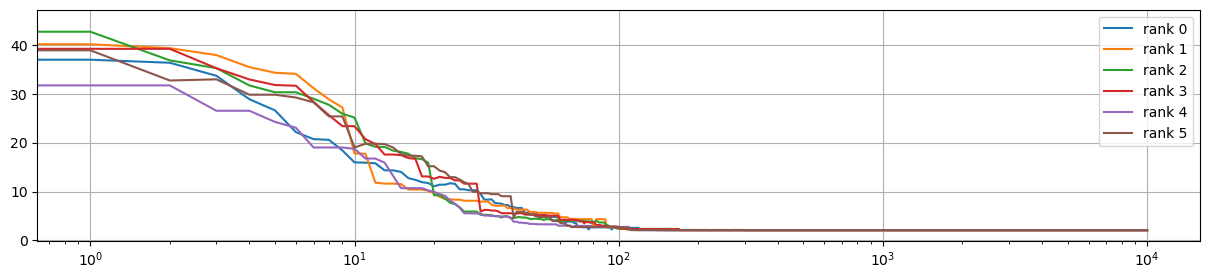

In [44]:
fig, ax = plt.subplots(figsize=(15, 3))
for k in range(6):


    best0=pd.read_csv(f'SOURCE/OUTPUT/circles/best_sol_rank_{k}.dat', skiprows=1, names=[f'c{j}' for j in range(35)]+['dist'])
    avg=pd.read_csv(f'SOURCE/OUTPUT/circles/avg_cost_rank_{k}.dat', skiprows=1, names=['avg_dist'])

    # print(best0)

    # x=np.array([circle_coord.iloc[int(j)-1].x for j in best0.iloc[len(best0.index)-1][:-1].array])
    # y=np.array([circle_coord.iloc[int(j)-1].y for j in best0.iloc[len(best0.index)-1][:-1].array])

    # plt.plot(x, y, '-o', ms=4)

    plt.plot(best0.dist, label=f'rank {k}')
# plt.ylim([0,5])
plt.legend()
plt.xscale('log')
plt.grid()
plt.show()

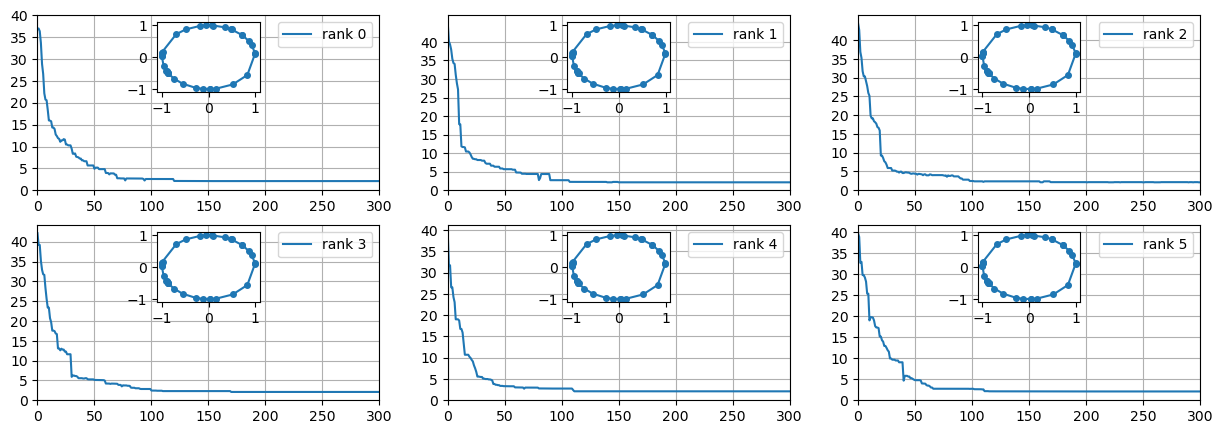

In [25]:
fig, axs = plt.subplots(2,3,figsize=(15, 5))
for k in range(6):

    ax = axs[k//3, k%3]

    best0=pd.read_csv(f'SOURCE/OUTPUT/best_sol_rank_{k}.dat', skiprows=1, names=[f'c{k}' for k in range(35)]+['dist'])
    ax.plot(best0.dist,label=f'rank {k}')

    sub_ax = inset_axes(
        parent_axes=ax,
        width="30%",
        height="40%",
        loc='upper center',
        borderpad=0.5  # padding between parent and inset axes
    )

    x=np.array([circle_coord.iloc[int(k)-1].x for k in best0.iloc[len(best0.index)-1][:-1].array])
    y=np.array([circle_coord.iloc[int(k)-1].y for k in best0.iloc[len(best0.index)-1][:-1].array])

    # plt.plot(x, y, '-o', ms=4)

    sub_ax.plot(x, y, '-o', ms=4)
    # sub_ax.get_xaxis().set_visible(False)
    # sub_ax.get_yaxis().set_visible(False)


    ax.legend()
    ax.set_xlim([0, 300])

    ax.set_yticks(range(0, 45, 5))
    ax.grid()
plt.show()

## ES 10.2


In [14]:
import geopandas as gpd

In [15]:
cap = pd.read_csv('SOURCE/cap_prov_ita.dat', sep=' ', names = ['x','y'])
italy = gpd.read_file('SOURCE/it.json')

In [22]:
def plot_rank(Nrank, dir, title='Distance L2 along optimization for different ranks \n Migration = True'):
    n=2
    fig, ax = plt.subplots(Nrank//n,n,figsize=(15, 5*n))
    fig.suptitle(title, y=0.99)
    # data_dir = "OUTPUT/square_setup1/"



    for j in range(Nrank):
        best0=pd.read_csv(f'SOURCE/OUTPUT/'+dir+f'/best_sol_rank_{j}.dat', skiprows=1, names=[f'c{k}' for k in range(111)]+['dist'])
        avg=pd.read_csv(f'SOURCE/OUTPUT/'+dir+f'/avg_cost_rank_{j}.dat', skiprows=1, names=['avg_dist'])

        ax[j//n, j%n].plot(best0.index, best0['dist'], '-', label = f"best") 
        ax[j//n, j%n].plot(avg.index, avg['avg_dist'], '-', label = f"avg") 
        ax[j//n, j%n].set_title(f'rank {j}: {best0.dist.min()}')

        ax[j//n, j%n].grid()
        ax[j//n, j%n].legend()
        ax[j//n, j%n].set_xlabel('evolution step')
        ax[j//n, j%n].set_ylabel('L2')
        # ax[j//n, j%n].set_xlim([0,1000])
        ax[j//n, j%n].set_ylim([50,200])

        sub_ax = inset_axes(
            parent_axes=ax[j//n, j%n],
            width="40%",
            height="80%",
            loc='upper center',
            borderpad=0.5  # padding between parent and inset axes
        )
        x=np.array([cap.iloc[int(k)-1].x for k in best0.iloc[len(best0)-1][:-1].array])
        y=np.array([cap.iloc[int(k)-1].y for k in best0.iloc[len(best0)-1][:-1].array])

        italy.plot(ax=sub_ax, markersize=.5)

        sub_ax.plot(x, y, '-o', ms=4, c='r')
        sub_ax.get_xaxis().set_visible(False)
        sub_ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()

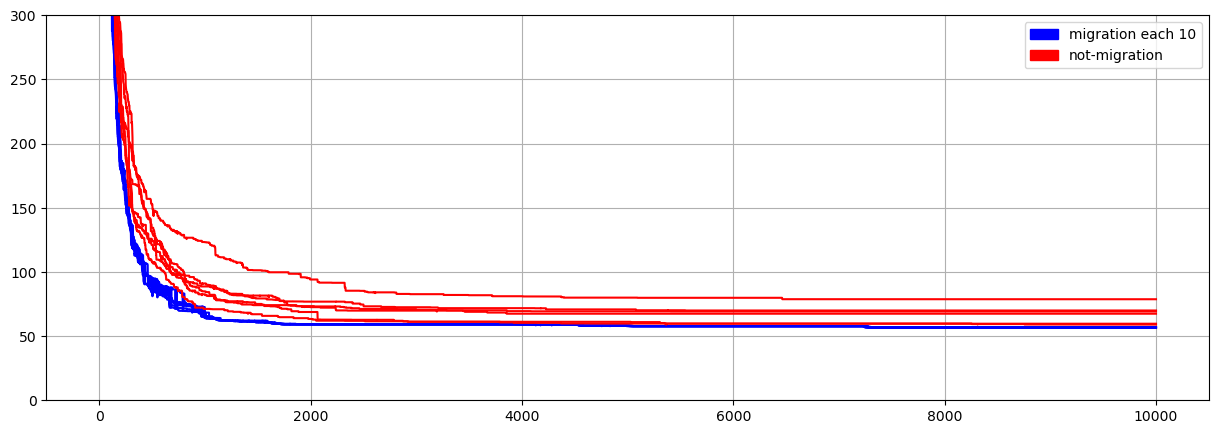

In [45]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1,1,figsize=(15, 5))
# plt.figure(figsize=(15, 5))
for k in range(6):
    best0=pd.read_csv(f'SOURCE/OUTPUT/italy_migration/best_sol_rank_{k}.dat', skiprows=1, names=[f'c{j}' for j in range(111)]+['dist'])
    plt.plot(best0.dist,label=f'migration rank {k}',c='b')
for k in range(6):
    best0=pd.read_csv(f'SOURCE/OUTPUT/italy_nonmigration/best_sol_rank_{k}.dat', skiprows=1, names=[f'c{j}' for j in range(111)]+['dist'])
    plt.plot(best0.dist,label=f'non migration rank {k}', c='r')

#plt.xlim([200, 1000])   
plt.ylim([0, 300])   
#plt.vlines(100, 0, 300)

mig = mpatches.Patch(color='blue', label='migration each 10')
notmig = mpatches.Patch(color='red', label='not-migration')

plt.legend(handles=[mig, notmig])
plt.grid()
plt.show()

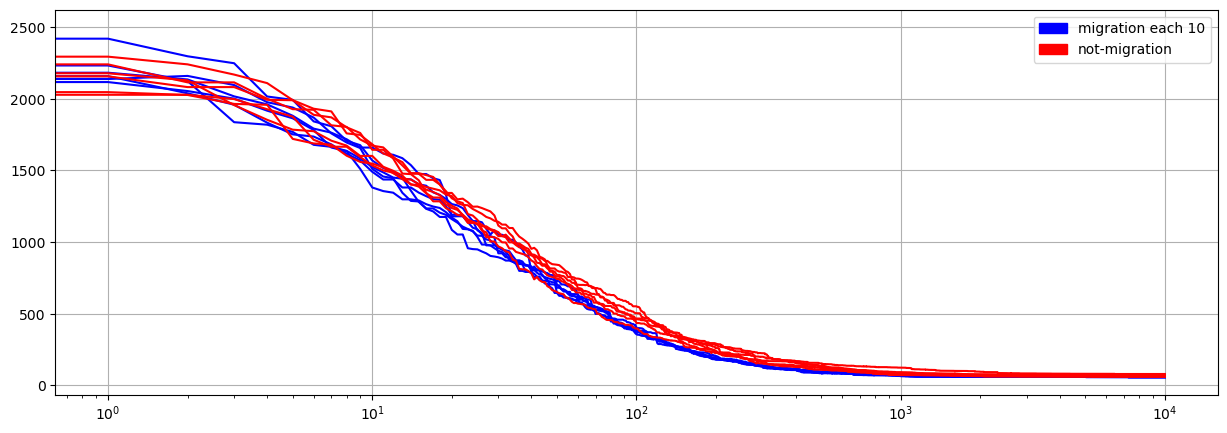

In [46]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1,1,figsize=(15, 5))
# plt.figure(figsize=(15, 5))
for k in range(6):
    best0=pd.read_csv(f'SOURCE/OUTPUT/italy_migration/best_sol_rank_{k}.dat', skiprows=1, names=[f'c{j}' for j in range(111)]+['dist'])
    plt.plot(best0.dist,label=f'migration rank {k}',c='b')
for k in range(6):
    best0=pd.read_csv(f'SOURCE/OUTPUT/italy_nonmigration/best_sol_rank_{k}.dat', skiprows=1, names=[f'c{j}' for j in range(111)]+['dist'])
    plt.plot(best0.dist,label=f'non migration rank {k}', c='r')

#plt.xlim([200, 1000])   
#plt.vlines(100, 0, 300)

mig = mpatches.Patch(color='blue', label='migration each 10')
notmig = mpatches.Patch(color='red', label='not-migration')

plt.legend(handles=[mig, notmig])
plt.grid()
plt.xscale('log')
plt.show()

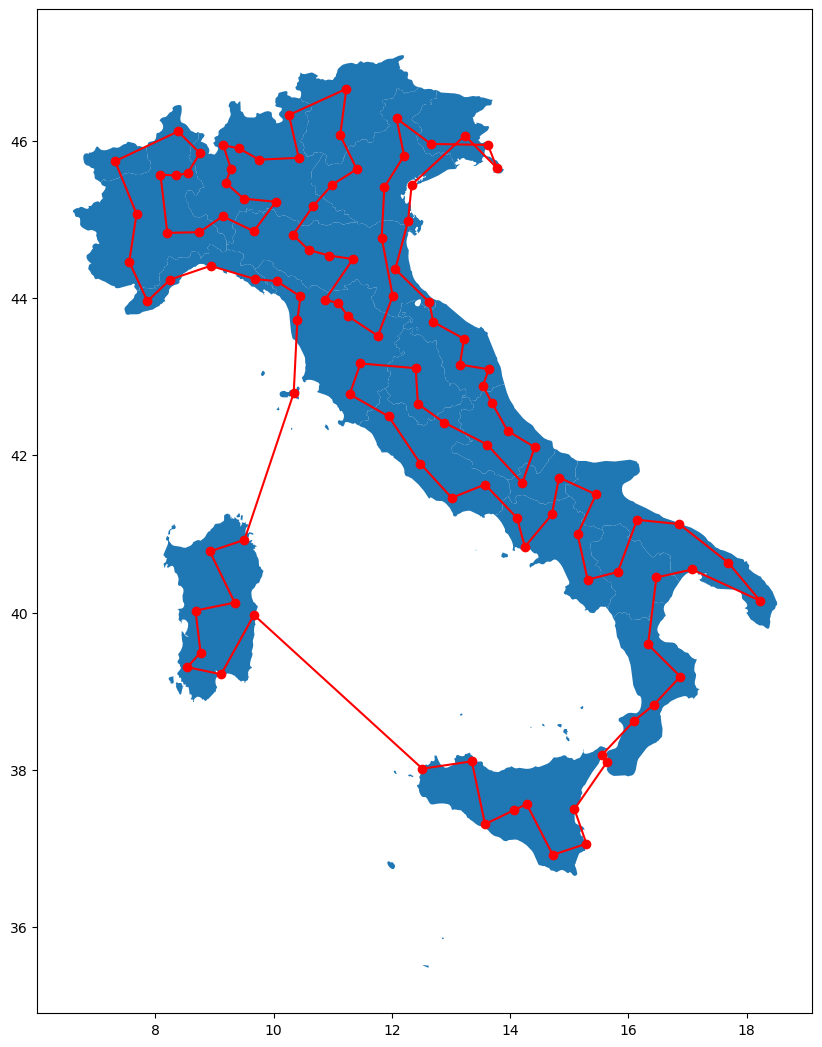

In [10]:
fig, ax = plt.subplots(figsize=(10, 20))

italy.plot(ax=ax, markersize=.5)
plt.scatter(cap.x, cap.y, c='r')

x=np.array([cap.iloc[int(k)-1].x for k in best0.iloc[len(best0)-1][:-1].array])
y=np.array([cap.iloc[int(k)-1].y for k in best0.iloc[len(best0)-1][:-1].array])

plt.plot(x, y, c='r')
plt.show()


/tmp/ipykernel_4374/1091052167.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


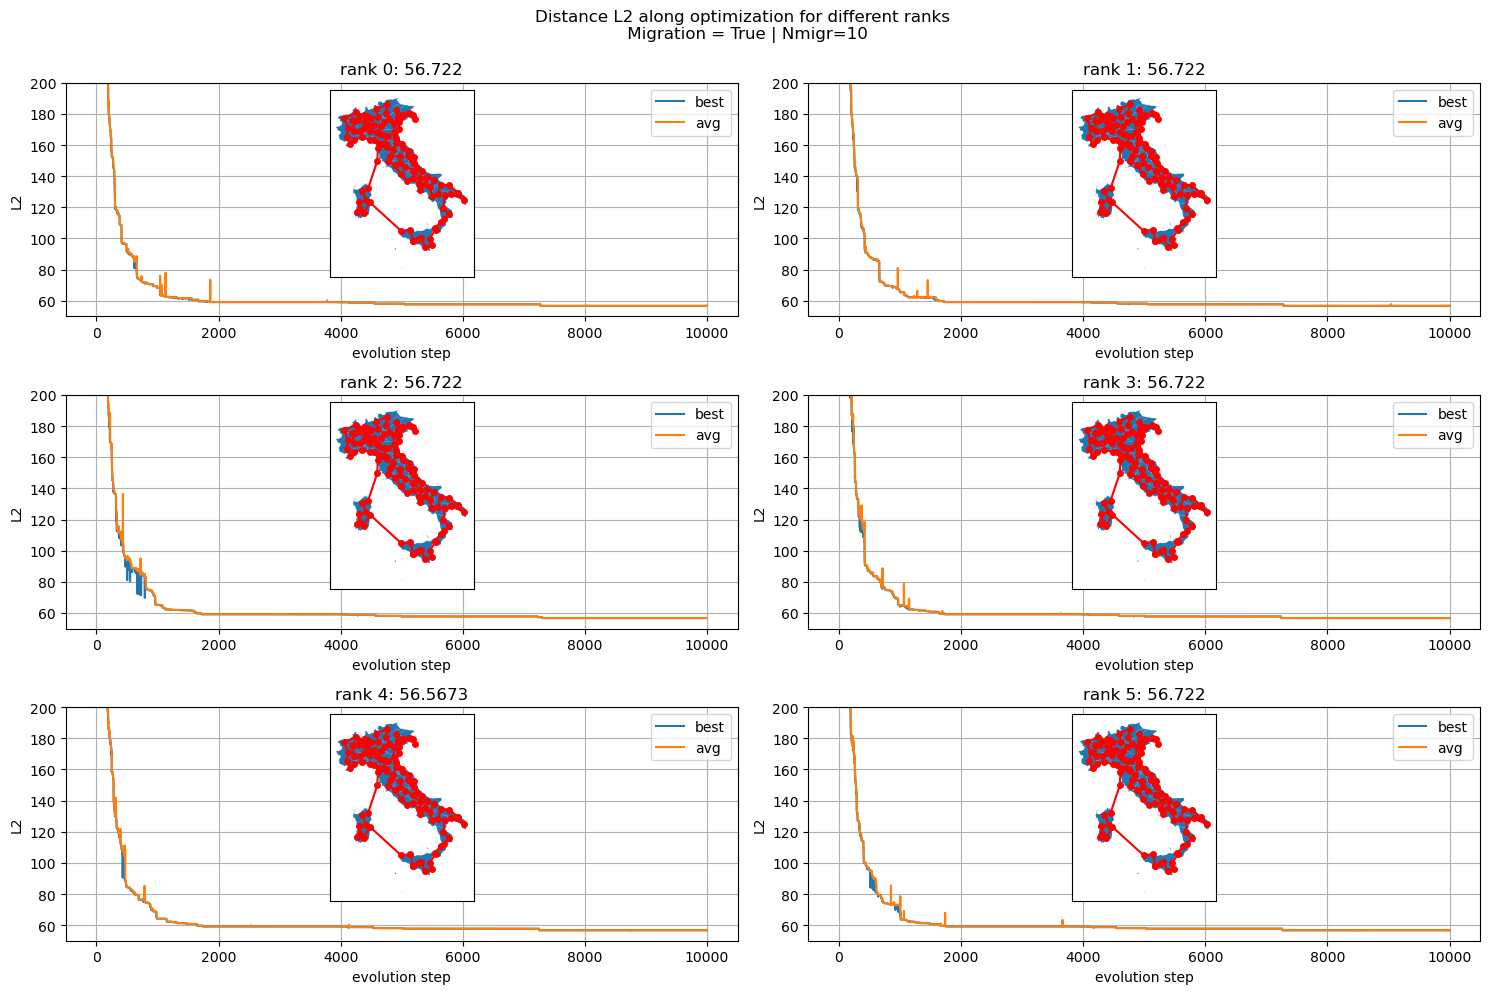

/tmp/ipykernel_4374/1091052167.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


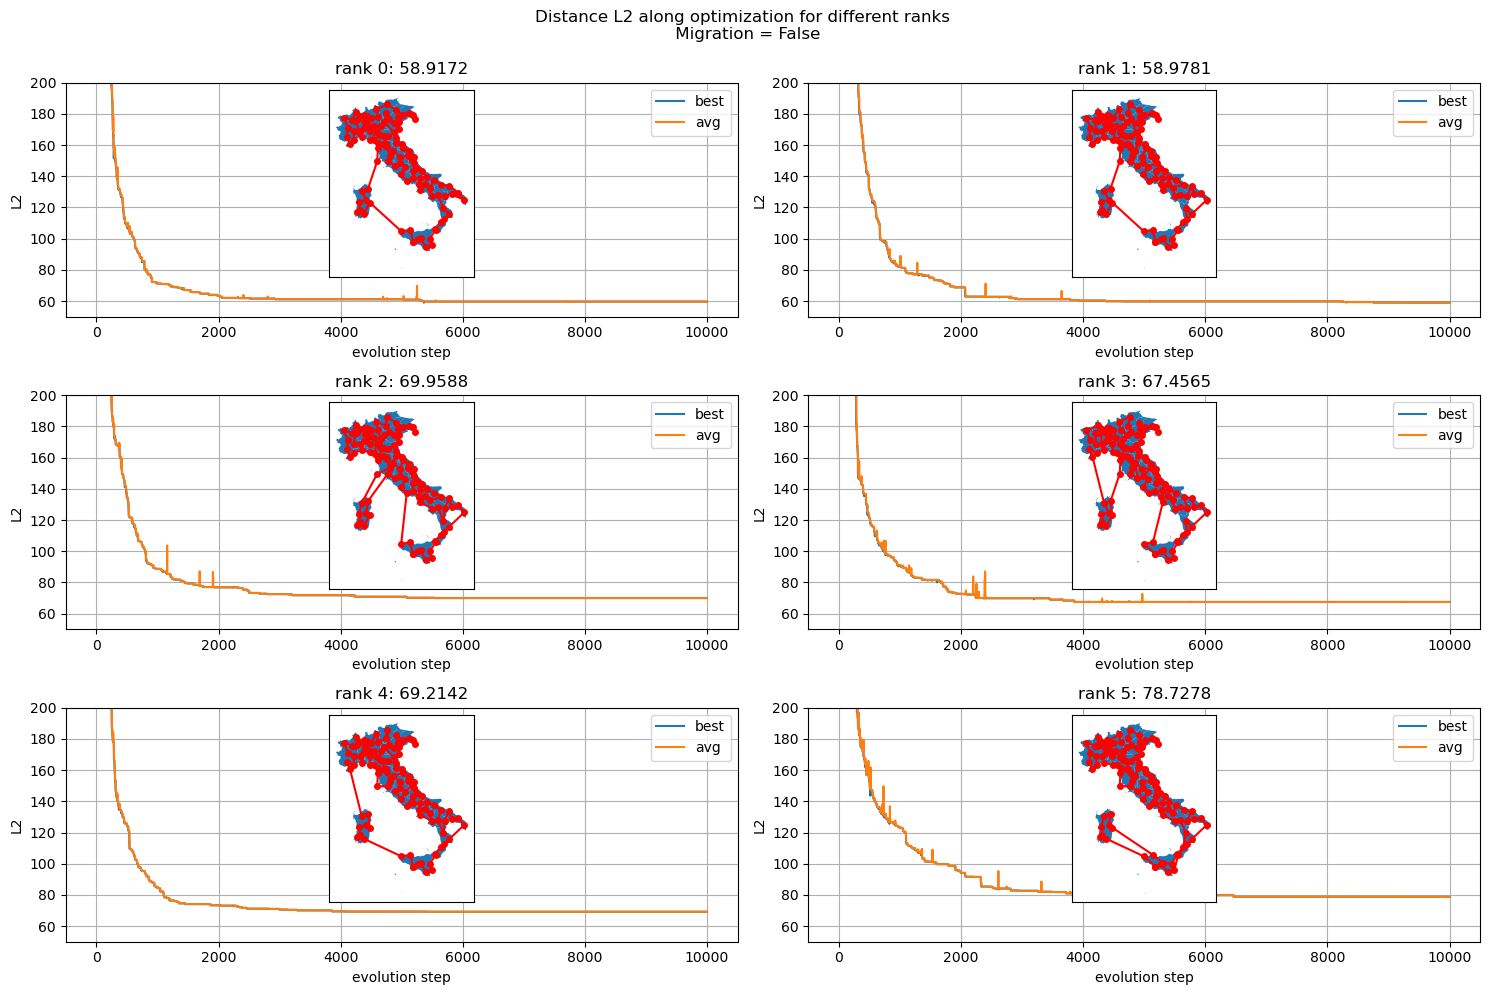

In [46]:
plot_rank(6, 'italy_migration', title='Distance L2 along optimization for different ranks \n Migration = True | Nmigr=10')
plot_rank(6, 'italy_nonmigration', title='Distance L2 along optimization for different ranks \n Migration = False')


Scrivere qualcosa commentando e mettendo link codice per creare gif [codice gif](animation.py)

Esempio di una run che finisce trovando effettivamente il minimo assoluto e una che non riesce a generarlo



rank = 0             |  rank = 1
:-------------------------:|:-------------------------:
![SegmentLocal](SOURCE/OUTPUT/gifs/animation_rank0.gif "segment") | ![SegmentLocal](SOURCE/OUTPUT/gifs/animation_rank1.gif "segment")


rank = 2             |  rank = 3
:-------------------------:|:-------------------------:
![SegmentLocal](SOURCE/OUTPUT/gifs/animation_rank2.gif "segment") | ![SegmentLocal](SOURCE/OUTPUT/gifs/animation_rank3.gif "segment")


## Varying Nmigr

In [6]:
import os

df=pd.DataFrame(columns=['Nmigr']+[f'rnk{k}' for k in range(6)])

for j, dir in enumerate(os.listdir('SOURCE/OUTPUT/varN/')):
    N=(int(dir.split('N')[1]))
    rnks=[]
    print(dir)
    for inputFile in os.listdir('SOURCE/OUTPUT/varN/'+dir):
        if not 'best_sol_rank' in inputFile:
            continue
        # print()
        # print(inputFile)
        with open('SOURCE/OUTPUT/varN/'+dir+'/'+inputFile, "r") as f1:
            last_line = f1.readlines()[-1]
            rnks.append(float(last_line.split(',')[-1]))
    df.loc[j]=[N]+rnks


N100
N10
N1
N20
N30
N40
N1000
N500
N200
N2
N3
N4
N5
N6
N7
N8
N300
N70
N700
N400
N800


In [7]:
df.sort_values(by='Nmigr',inplace=True)
df.reset_index(drop=True, inplace=True)

df['mean']=df[[f'rnk{j}' for j in range(6)]].mean(axis=1)
df['sig']=df[[f'rnk{j}' for j in range(6)]].std(axis=1)


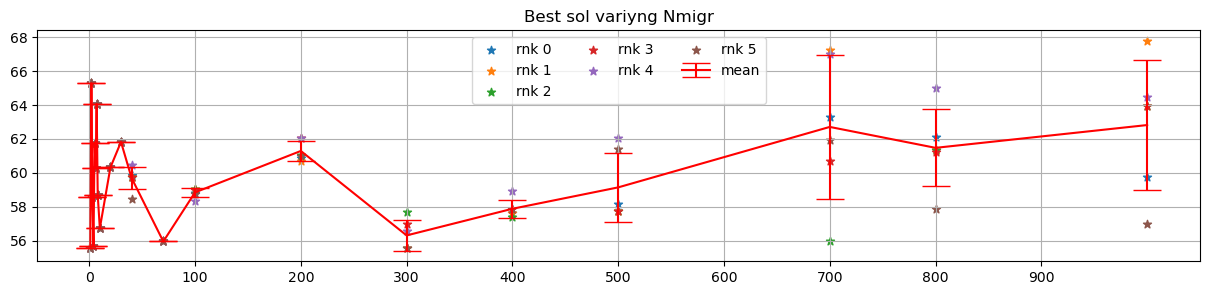

In [8]:
plt.figure(figsize=(15, 3))
plt.title('Best sol variyng Nmigr')
for k in range(6):
    plt.scatter(df.Nmigr,df[f'rnk{k}'],label=f'rnk {k}', marker='*')

plt.xticks(range(0,int(df.Nmigr.max()), 10)[::10])

plt.errorbar(x=df.Nmigr, y=df['mean'], yerr=df['sig'], capsize=10,c='r',label='mean')
plt.grid()
plt.legend(ncol=3)

# plt.xscale('log')
plt.show()

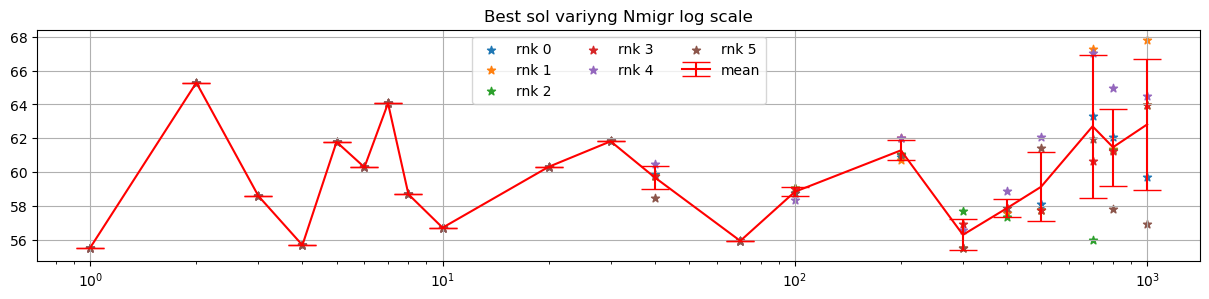

In [9]:
plt.figure(figsize=(15, 3))
plt.title('Best sol variyng Nmigr log scale')
for k in range(6):
    plt.scatter(df.Nmigr,df[f'rnk{k}'],label=f'rnk {k}', marker='*')

plt.xticks(range(0,int(df.Nmigr.max()), 10)[::10])

plt.errorbar(x=df.Nmigr, y=df['mean'], yerr=df['sig'], capsize=10,c='r',label='mean')
plt.grid()
plt.legend(ncol=3)
plt.xscale('log')
plt.show()

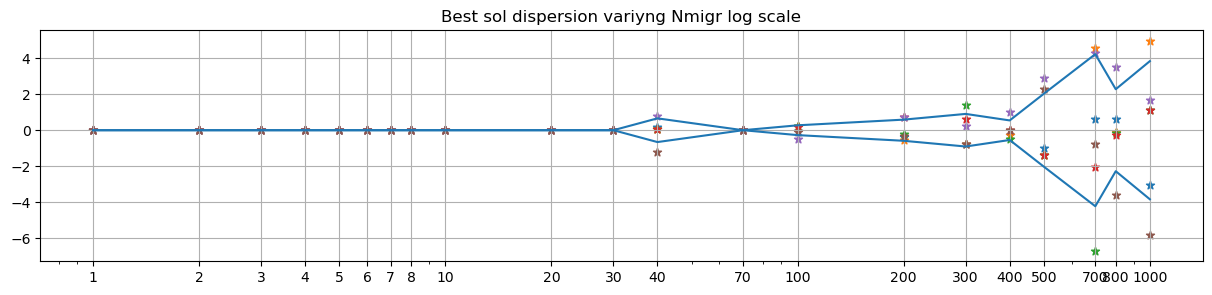

In [10]:
plt.figure(figsize=(15, 3))
plt.title('Best sol dispersion variyng Nmigr log scale')
for k in range(6):
    plt.scatter(df.Nmigr,df[f'rnk{k}']-df['mean'],label=f'rnk {k}', marker='*')
# plt.plot(df.Nmigr, df['mean'],c='r',label='mean')
plt.plot(df.Nmigr, df['sig'])
plt.plot(df.Nmigr, -df['sig'],c='C0')
plt.grid()
#plt.legend(loc='left')
plt.xscale('log')
plt.xticks(df.Nmigr, df.Nmigr.array.astype(int))
plt.show()

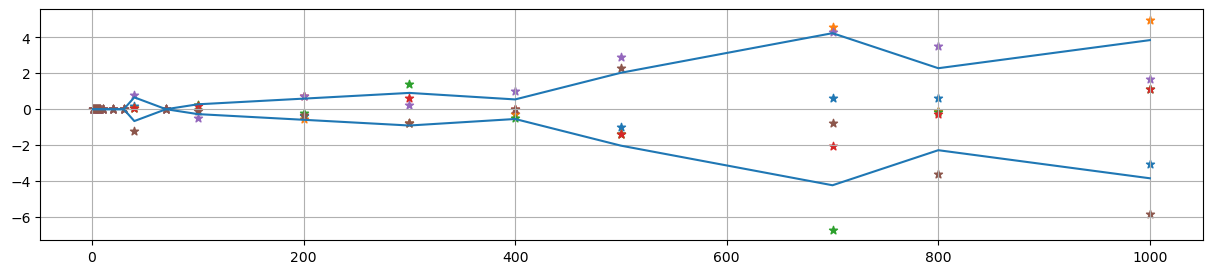

In [11]:
plt.figure(figsize=(15, 3))
for k in range(6):
    plt.scatter(df.Nmigr,df[f'rnk{k}']-df['mean'],label=f'rnk {k}', marker='*')
# plt.plot(df.Nmigr, df['mean'],c='r',label='mean')
plt.plot(df.Nmigr, df['sig'])
plt.plot(df.Nmigr, -df['sig'],c='C0')
plt.grid()
#plt.legend(loc='left')
# plt.xscale('log')
# plt.xticks(df.Nmigr, df.Nmigr.array.astype(int))
plt.show()